In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


In [61]:
df=pd.read_csv("netflix_titles.csv")



In [62]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [63]:
df = df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'rating': 'Unknown'
})

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Missing values after cleaning:\n", df.isnull().sum())
print("\nMovies vs TV Shows:")
print(df['type'].value_counts())

Missing values after cleaning:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      98
month_added     98
dtype: int64

Movies vs TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [64]:
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

fig = px.pie(type_counts, 
             values='count', 
             names='type',
             title='Movies vs TV Shows on Netflix',
             color_discrete_sequence=['red', 'black'])

fig.update_traces(textinfo='percent+label+value')
fig.show()

In [65]:
country_df = df[df['country'] != 'Unknown']
top_countries = country_df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Count']

fig = px.bar(top_countries,
             x='Count',
             y='Country',
             orientation='h',
             title='Top 10 Countries Producing Netflix Content',
             color='Count',
             color_continuous_scale='tempo')

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [66]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15).reset_index()
top_genres.columns = ['Genre', 'Count']

fig = px.bar(top_genres,
             x='Count',
             y='Genre',
             orientation='h',
             title='Top 15 Most Common Genres on Netflix',
             color='Count',
             color_continuous_scale='Plasma')

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [67]:
ratings = df[df['rating'] != 'Unknown']['rating'].value_counts().reset_index()
ratings.columns = ['Rating', 'Count']

fig = px.bar(ratings,
             x='Rating',
             y='Count',
             title='Netflix Content by Age Rating',
             color='Count',
             color_continuous_scale='Sunset')

fig.show()

In [68]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.replace(' min', '').astype(float)

fig = px.histogram(movies,
                   x='duration_mins',
                   title='Distribution of Movie Durations on Netflix',
                   color_discrete_sequence=['Purple'],
                   nbins=30)

fig.update_layout(xaxis_title='Duration (minutes)',
                  yaxis_title='Number of Movies')
fig.show()

In [69]:
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = shows['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)

season_counts = shows['seasons'].value_counts().sort_index().reset_index()
season_counts.columns = ['Seasons', 'Count']

fig = px.bar(season_counts,
             x='Seasons',
             y='Count',
             title='How Many Seasons Do Netflix TV Shows Have?',
             color='Count',
             color_continuous_scale='tropic')
fig.show()

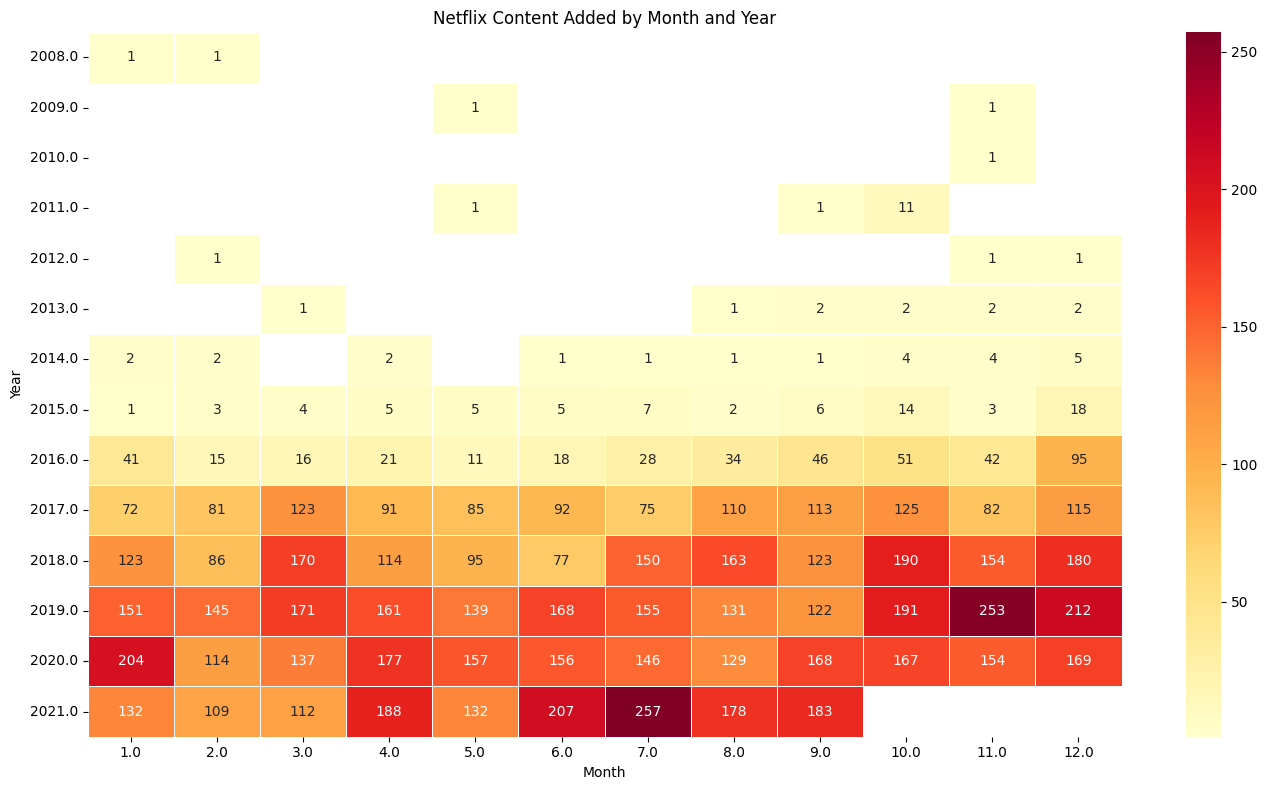

In [70]:

pivot = df.groupby(['year_added', 'month_added'])['title'].count().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, 
            cmap='YlOrRd',
            linewidths=0.5,
            annot=True,
            fmt='g')

plt.title('Netflix Content Added by Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('heatmap_monthly.png')
plt.show()

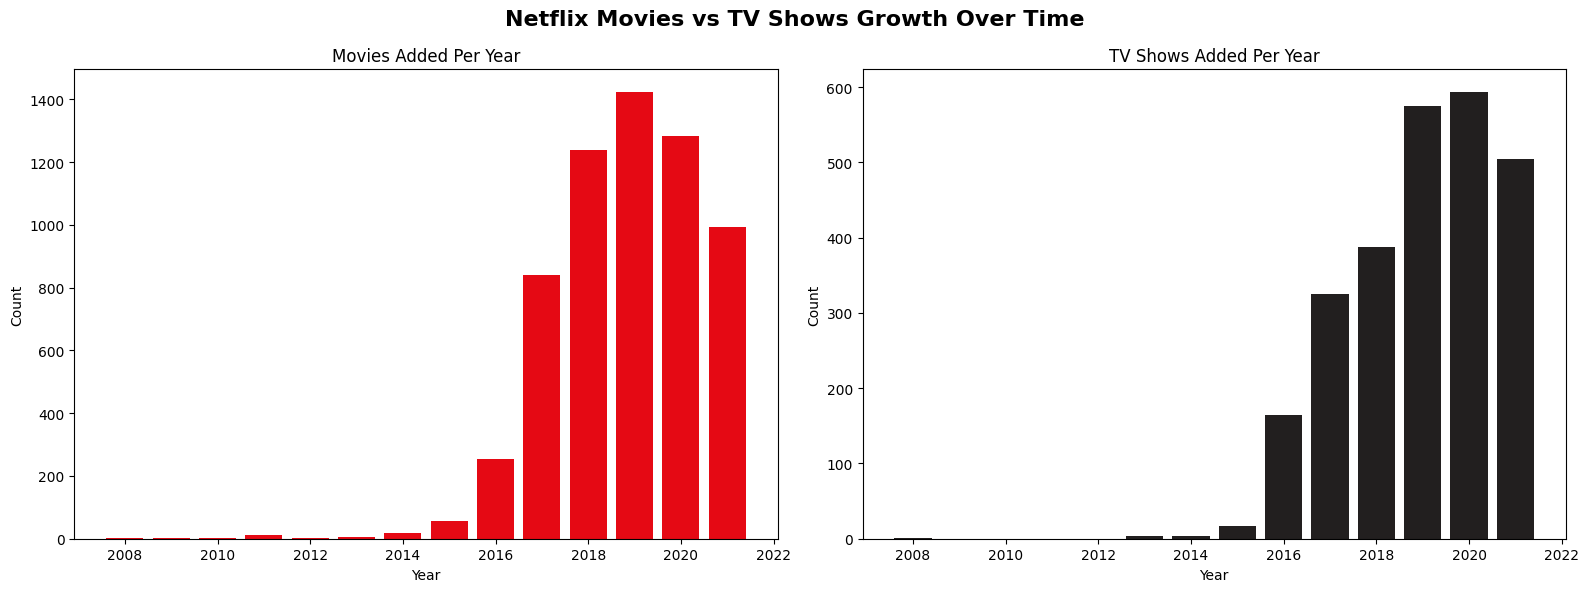

In [71]:

movies_by_year = df[df['type'] == 'Movie'].groupby('year_added')['title'].count()
shows_by_year = df[df['type'] == 'TV Show'].groupby('year_added')['title'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movies
ax1.bar(movies_by_year.index, movies_by_year.values, color='#E50914')
ax1.set_title('Movies Added Per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')

# TV Shows
ax2.bar(shows_by_year.index, shows_by_year.values, color='#221F1F')
ax2.set_title('TV Shows Added Per Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Count')

plt.suptitle('Netflix Movies vs TV Shows Growth Over Time', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('movies_vs_shows_growth.png')
plt.show()